In [1]:
import pandas as  pd
train = pd.read_csv('train_split_temporal_60.csv')
test= pd.read_csv('test_split_temporal_40.csv')


In [2]:
test.head()

,main_name,BY,CD + BY,CD,SW_%,KW_%,LF_%,ST_%,Time,Volume
0,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,9.353557,169.426325
1,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,9.392770,169.567399
2,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,9.432363,169.708119
3,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,9.472396,169.848441
4,BY + 40% SW + 60% KW,1,0,0,40.0,60.0,0.0,0.0,9.512928,169.988320


In [3]:
predicted= "predicted test data.csv"
prediction = pd.read_csv(predicted,header=2)
prediction.head()

,Unnamed: 0,Unnamed: 1,Predicted_Test,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,NaN,169.9035,NaN,NaN,NaN
1,NaN,NaN,170.3387,NaN,NaN,NaN
2,NaN,NaN,170.7750,NaN,NaN,NaN
3,NaN,NaN,171.2132,NaN,NaN,NaN
4,NaN,NaN,171.6536,NaN,NaN,NaN


In [4]:
# Check row counts before adding Time
len_prediction = len(prediction)
len_test = len(test)

print(f"prediction rows: {len_prediction}")
print(f"test rows: {len_test}")

if len_prediction != len_test:
    raise ValueError("Length mismatch: cannot add Time column from test to prediction.")
    
# Add Time column from test
prediction["Time"] = test["Time"].reset_index(drop=True)
prediction["main_name"] = test["main_name"].reset_index(drop=True)

# Verify
prediction.head()

prediction rows: 5267
test rows: 5267


,Unnamed: 0,Unnamed: 1,Predicted_Test,Unnamed: 3,Unnamed: 4,Unnamed: 5,Time,main_name
0,NaN,NaN,169.9035,NaN,NaN,NaN,9.353557,BY + 40% SW + 60% KW
1,NaN,NaN,170.3387,NaN,NaN,NaN,9.392770,BY + 40% SW + 60% KW
2,NaN,NaN,170.7750,NaN,NaN,NaN,9.432363,BY + 40% SW + 60% KW
3,NaN,NaN,171.2132,NaN,NaN,NaN,9.472396,BY + 40% SW + 60% KW
4,NaN,NaN,171.6536,NaN,NaN,NaN,9.512928,BY + 40% SW + 60% KW


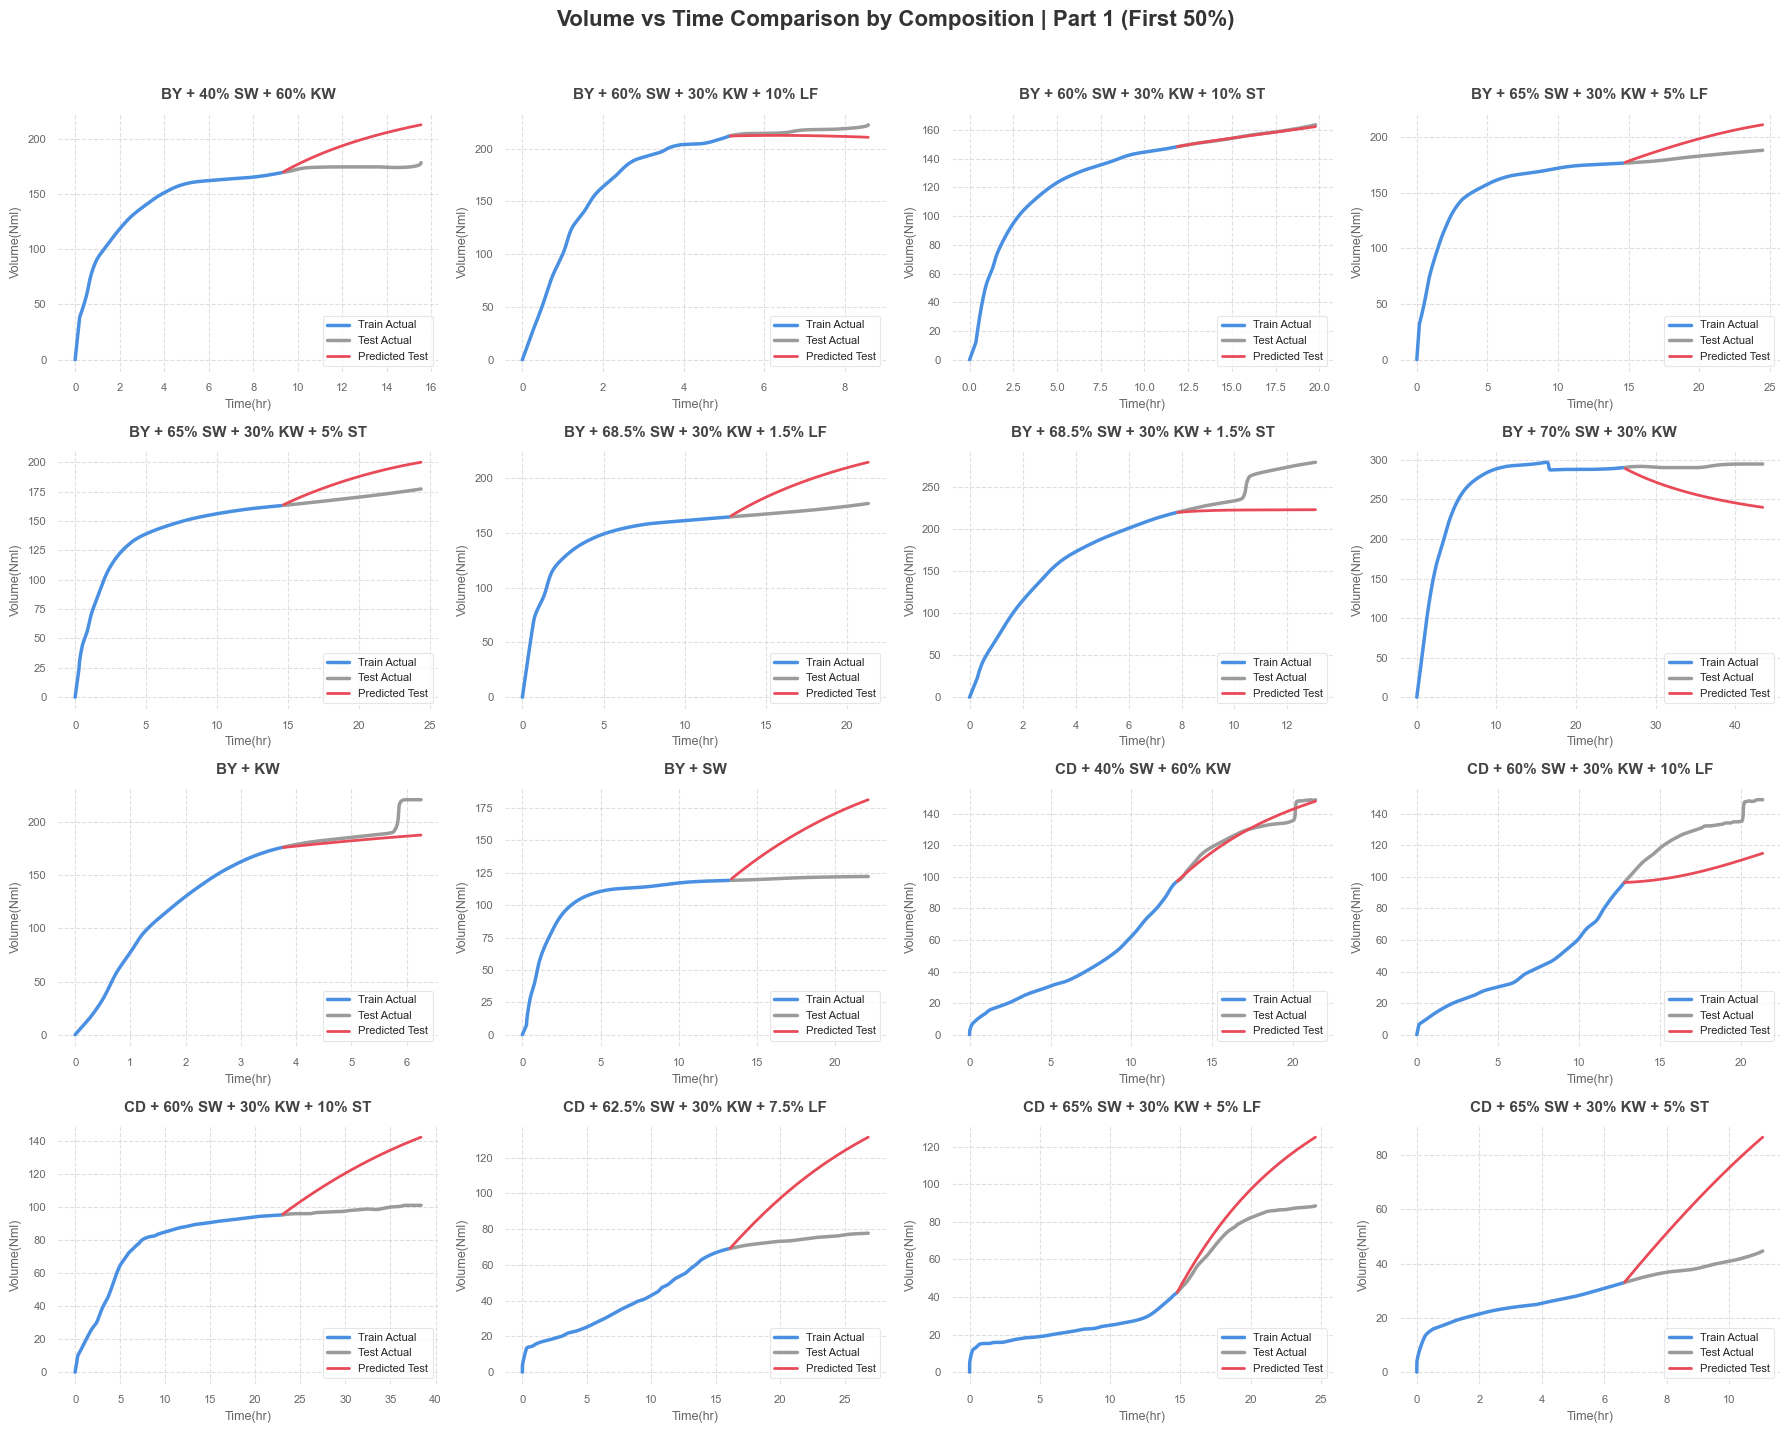

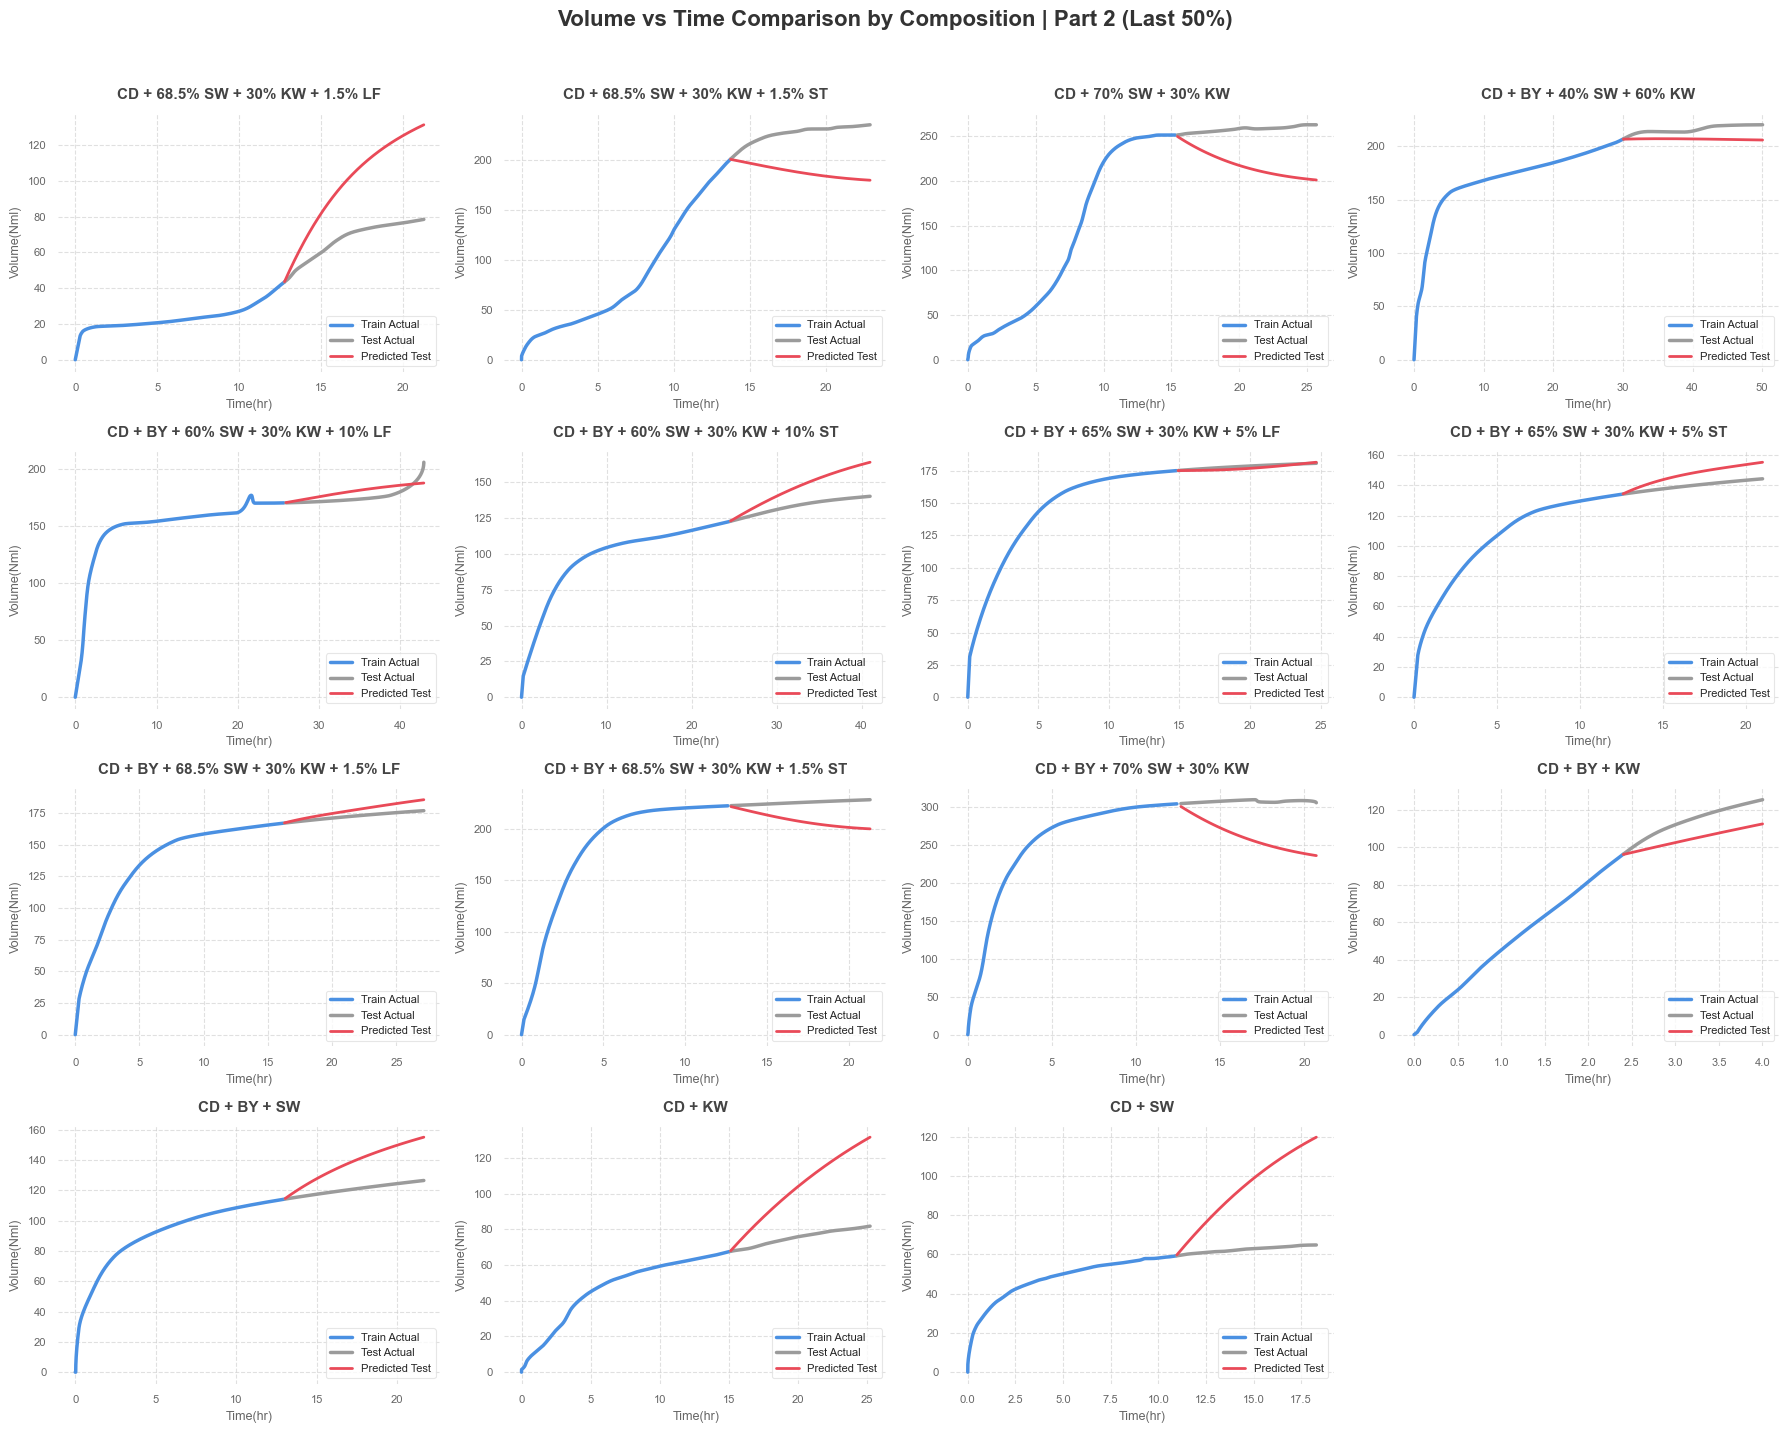

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Set up minimalist and pleasing aesthetics
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.edgecolor': '#E0E0E0',
    'axes.linewidth': 1,
    'grid.alpha': 0.6,
    'grid.linestyle': '--',
    'legend.frameon': True,
    'legend.edgecolor': '#E0E0E0',
})

# Colors
color_train = '#4A90E2' # Blue for Train
color_test = '#9B9B9B'  # Gray for True Test
color_pred = '#E94A58'  # Red for Prediction

# Get unique main names to iterate over
main_names = train['main_name'].unique()
half_idx = math.ceil(len(main_names) / 2)

# Split into two parts
parts = [
    (main_names[:half_idx], "Part 1 (First 50%)"),
    (main_names[half_idx:], "Part 2 (Last 50%)")
]

for names, subtitle in parts:
    num_plots = len(names)
    cols = 4
    rows = math.ceil(num_plots / cols)

    # Create figure and axes for this part
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5))
    fig.suptitle(f'Volume vs Time Comparison by Composition | {subtitle}', fontsize=16, fontweight='bold', y=1.02, color='#333333')
    axes = axes.flatten()

    for i, name in enumerate(names):
        ax = axes[i]
        
        # Filter datasets by main_name
        df_train = train[train['main_name'] == name]
        df_test = test[test['main_name'] == name]
        df_pred = prediction[prediction['main_name'] == name]
        
        # Plot Traing Data
        ax.plot(df_train['Time'], df_train['Volume'], color=color_train, label='Train Actual', linewidth=2.5)
        
        # Plot Testing Data
        ax.plot(df_test['Time'], df_test['Volume'], color=color_test, label='Test Actual', linewidth=2.5, zorder=2)
        
        # Plot Predicted Data
        ax.plot(df_pred['Time'], df_pred['Predicted_Test'], color=color_pred, label='Predicted Test', linewidth=2, zorder=3)
        
        # Labels and Titles
        ax.set_title(name, fontsize=11, fontweight='bold', color='#444444', pad=10)
        ax.set_xlabel('Time(hr)', fontsize=9, color='#666666')
        ax.set_ylabel('Volume(Nml)', fontsize=9, color='#666666')
        ax.tick_params(axis='both', colors='#666666', labelsize=8)
        
        # Legend
        ax.legend(loc='lower right', fontsize=8)

    # Remove any unused subplot axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()